# **EDA** (Exploratory Data Analysis)

### Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Loading data and first insights**

The goal is loading of data from `.xlsx` to dataframe and see first insights like number of rows and number of columns.

In [2]:
def load_data():
    loaded_data = []

    for i in range(7):
        data = pd.read_excel(f"../data/raw/nez-opendata-202{i}.xlsx")

        data.columns = ['accident_id', 'department', 'municipality', 'date_time', 'longitude', 'latitude', 'accident_type', 'involved_vehicles_num', 'description']
        
        # Date and Time parsing
        data['date_time'] = pd.to_datetime(
            data['date_time'],
            format = "%d.%m.%Y,%H:%M",
            errors = "coerce"
        )

        loaded_data.append(data)
    
    return pd.concat(loaded_data, ignore_index=True)

In [3]:
data = load_data()

In [4]:
data.head()

,accident_id,department,municipality,date_time,longitude,latitude,accident_type,involved_vehicles_num,description
0,1278576,BEOGRAD,BARAJEVO,2020-01-07 10:10:00,20.301589,44.568563,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...
1,1278948,BEOGRAD,BARAJEVO,2020-01-09 12:50:00,20.413280,44.579780,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...
2,1278074,BEOGRAD,BARAJEVO,2020-01-10 10:05:00,20.312560,44.575470,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...
3,1278582,BEOGRAD,BARAJEVO,2020-01-10 15:15:00,20.412190,44.637770,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću različitim p...
4,1278638,BEOGRAD,BARAJEVO,2020-01-16 16:45:00,20.381686,44.633030,Sa povredjenim,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...


In [5]:
data.shape

(205352, 9)

### **Understanding of structure**

The goal is checking types of data (number, category, date), missing values, duplicates and descriptive statistics.

In [6]:
data.dtypes

accident_id                       int64
department                       object
municipality                     object
date_time                datetime64[ns]
longitude                       float64
latitude                        float64
accident_type                    object
involved_vehicles_num            object
description                      object
dtype: object

In [7]:
data.isna().sum()

accident_id              0
department               0
municipality             0
date_time                0
longitude                0
latitude                 0
accident_type            0
involved_vehicles_num    0
description              0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(12)

In [9]:
data[data.duplicated()]

,accident_id,department,municipality,date_time,longitude,latitude,accident_type,involved_vehicles_num,description
3325,1302492,BEOGRAD,OBRENOVAC,2020-10-18 23:10:00,20.277090,44.659419,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i životinja
13467,1291853,BEOGRAD,ČUKARICA,2020-06-27 09:50:00,20.421833,44.785551,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...
40422,1329694,BEOGRAD,VOŽDOVAC,2021-07-20 01:30:00,20.484483,44.783126,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom na kolovozu
60048,1333269,SREMSKA MITROVICA,SREMSKA MITROVICA,2021-09-02 13:50:00,19.620961,44.969459,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Ostale nezgode sa najmanje dva vozila – suprot...
81186,1375079,JAGODINA,PARAĆIN,2022-06-16 10:03:00,21.618985,43.857867,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...
93994,1392887,SREMSKA MITROVICA,ŠID,2022-09-24 18:15:00,19.343341,45.075567,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...
114060,1450561,JAGODINA,PARAĆIN,2023-11-03 16:40:00,21.518745,43.860743,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i životinja
169549,1534727,BEOGRAD,RAKOVICA,2025-07-24 13:55:00,20.447884,44.744817,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...
182556,1513562,LESKOVAC,LESKOVAC,2025-02-20 10:40:00,21.924095,42.996794,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...
200566,1565231,BEOGRAD,ZEMUN,2026-02-26 22:00:00,20.304828,44.918957,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgode sa učešćem jednog vozila i preprekama ...


In [10]:
data.drop_duplicates(inplace=True)

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data = data.drop_duplicates(subset=['accident_id'], keep='first')

In [13]:
data.shape

(203965, 9)

In [14]:
removed_rows_num = 205352 - 203965
print(f"Number of duplicate rows removed: {removed_rows_num}")

Number of duplicate rows removed: 1387


In [15]:
data['department'].unique()

array(['BEOGRAD', 'BOR', 'JAGODINA', 'KIKINDA', 'KRAGUJEVAC', 'KRALJEVO',
       'KRUŠEVAC', 'LESKOVAC', 'NIŠ', 'NOVI PAZAR', 'NOVI SAD', 'PANČEVO',
       'PIROT', 'POŽAREVAC', 'PRIJEPOLJE', 'PROKUPLJE', 'SMEDEREVO',
       'SOMBOR', 'SREMSKA MITROVICA', 'SUBOTICA', 'UŽICE', 'VALJEVO',
       'VRANJE', 'ZAJEČAR', 'ZRENJANIN', 'ČAČAK', 'ŠABAC'], dtype=object)

In [16]:
len(data['department'].unique())

27

In [17]:
data['municipality'].unique()

array(['BARAJEVO', 'GROCKA', 'LAZAREVAC', 'MLADENOVAC', 'NOVI BEOGRAD',
       'OBRENOVAC', 'PALILULA', 'RAKOVICA', 'SAVSKI VENAC', 'SOPOT',
       'STARI GRAD', 'SURČIN', 'VOŽDOVAC', 'VRAČAR', 'ZEMUN', 'ZVEZDARA',
       'ČUKARICA', 'BOR', 'KLADOVO', 'MAJDANPEK', 'NEGOTIN', 'DESPOTOVAC',
       'JAGODINA', 'PARAĆIN', 'REKOVAC', 'SVILAJNAC', 'ĆUPRIJA', 'ADA',
       'KANJIŽA', 'KIKINDA', 'NOVI KNEŽEVAC', 'SENTA', 'ČOKA',
       'ARANĐELOVAC', 'BATOČINA', 'KNIĆ', 'KRAGUJEVAC', 'LAPOVO', 'RAČA',
       'TOPOLA', 'KRALJEVO', 'RAŠKA', 'VRNJAČKA BANJA', 'ALEKSANDROVAC',
       'BRUS', 'KRUŠEVAC', 'TRSTENIK', 'VARVARIN', 'ĆIĆEVAC', 'BOJNIK',
       'CRNA TRAVA', 'LEBANE', 'LESKOVAC', 'MEDVEĐA', 'VLASOTINCE',
       'ALEKSINAC', 'DOLJEVAC', 'GADŽIN HAN', 'MEROŠINA', 'NIŠ',
       'NIŠKA BANJA', 'RAŽANJ', 'SVRLJIG', 'NOVI PAZAR', 'SJENICA',
       'TUTIN', 'BAČ', 'BAČKA PALANKA', 'BAČKI PETROVAC', 'BEOČIN',
       'BEČEJ', 'NOVI SAD', 'SRBOBRAN', 'SREMSKI KARLOVCI', 'TEMERIN',
       'TITEL', 

In [18]:
len(data['municipality'].unique())

162

In [19]:
data['accident_type'].unique()

array(['Sa mat.stetom', 'Sa povredjenim', 'Sa poginulim'], dtype=object)

In [20]:
data['involved_vehicles_num'].unique()

array(['SN SA JEDNIM VOZILOM',
       'SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA',
       'SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PRELAZAK',
       'SN SA PARKIRANIM VOZILIMA', 'SN SA PEŠACIMA'], dtype=object)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203965 entries, 0 to 205351
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   accident_id            203965 non-null  int64         
 1   department             203965 non-null  object        
 2   municipality           203965 non-null  object        
 3   date_time              203965 non-null  datetime64[ns]
 4   longitude              203965 non-null  float64       
 5   latitude               203965 non-null  float64       
 6   accident_type          203965 non-null  object        
 7   involved_vehicles_num  203965 non-null  object        
 8   description            203965 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 15.6+ MB


In [22]:
data.describe(include='object')

,department,municipality,accident_type,involved_vehicles_num,description
count,203965,203965,203965,203965,203965
unique,27,162,3,5,68
top,BEOGRAD,NOVI SAD,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...
freq,89680,13251,121989,62231,27030


### **Univariate analysis**

The goal is to inspect each feature separately and try to find more insights on them. For numerical by using histogram and box plot to see shape of distribution and find outliers (values that are far from rest). For categorical by using bar chart to see frequency, is it rare or dominant category, ...

##### **Feature:** `Department`

In [23]:
sorted_by_departpemnt = data.groupby('department').size().sort_values(ascending=False)
sorted_by_departpemnt

department
BEOGRAD              89680
NOVI SAD             19024
NIŠ                   8010
SREMSKA MITROVICA     7108
ŠABAC                 6578
KRAGUJEVAC            6060
SMEDEREVO             5190
VALJEVO               4812
POŽAREVAC             4620
PANČEVO               4594
KRUŠEVAC              4292
JAGODINA              4273
UŽICE                 4041
KRALJEVO              3922
ČAČAK                 3853
SOMBOR                3571
VRANJE                3272
SUBOTICA              3210
LESKOVAC              2740
ZRENJANIN             2729
NOVI PAZAR            2722
KIKINDA               2431
BOR                   2149
ZAJEČAR               1866
PIROT                 1189
PROKUPLJE             1082
PRIJEPOLJE             947
dtype: int64

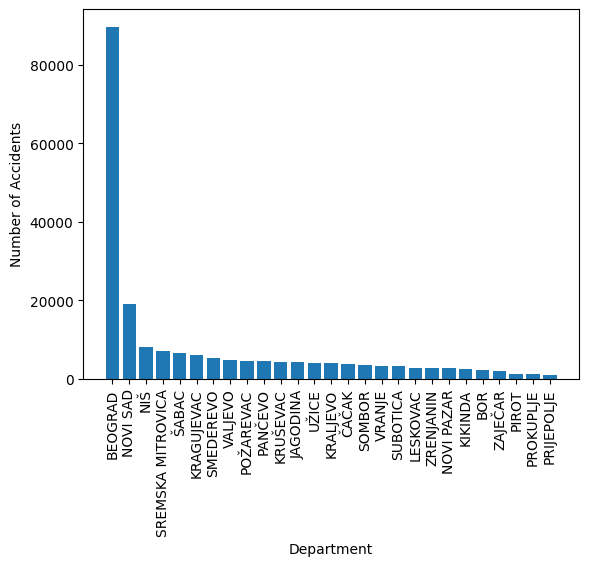

In [35]:
plt.figure()
plt.bar(sorted_by_departpemnt.index, sorted_by_departpemnt.values)
plt.xlabel("Department")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

##### **Feature:** `Municipality`

In [44]:
sorted_by_municipality = data.groupby('municipality').size().sort_values(ascending=False)
sorted_by_municipality

municipality
NOVI SAD        13251
NOVI BEOGRAD    11806
VOŽDOVAC        10230
PALILULA         9506
ČUKARICA         8283
                ...  
NOVA CRNJA         71
MEDVEĐA            56
TRGOVIŠTE          54
BOSILEGRAD         48
CRNA TRAVA         19
Length: 162, dtype: int64

In [46]:
sorted_by_municipality = sorted_by_municipality.iloc[:30]

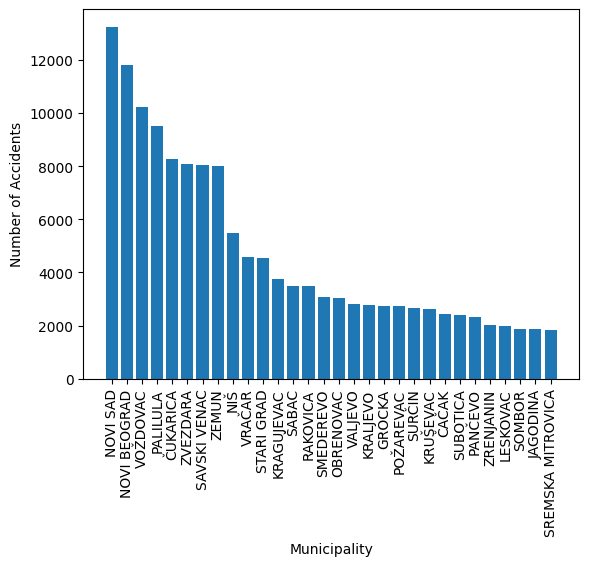

In [47]:
plt.figure()
plt.bar(sorted_by_municipality.index, sorted_by_municipality.values)
plt.xlabel("Municipality")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

##### **Feature:** `Accident Type`

In [50]:
sorted_by_acc_type = data.groupby('accident_type').size().sort_values(ascending=False)
sorted_by_acc_type

accident_type
Sa mat.stetom     121989
Sa povredjenim     79051
Sa poginulim        2925
dtype: int64

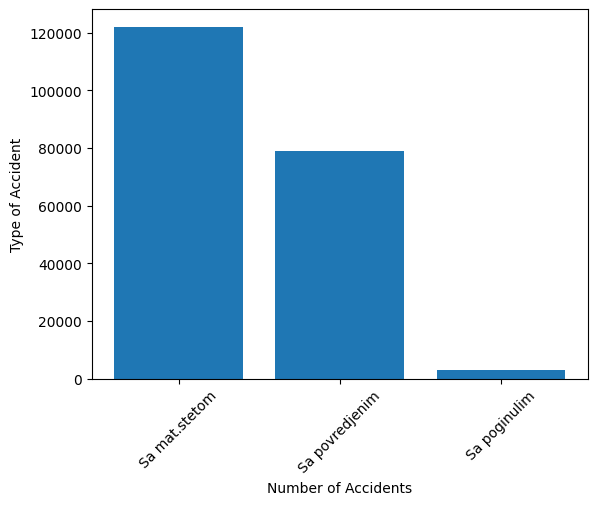

In [52]:
plt.figure()
plt.bar(sorted_by_acc_type.index, sorted_by_acc_type.values)
plt.xlabel("Number of Accidents")
plt.ylabel("Type of Accident")
plt.xticks(rotation=45)
plt.show()

##### **Feature:** `Involved Vehicles Number`

In [32]:
sorted_by_involved_vehicles_num = data.groupby('involved_vehicles_num').size().sort_values(ascending=False)
sorted_by_involved_vehicles_num

involved_vehicles_num
SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA             62231
SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PRELAZAK    49543
SN SA JEDNIM VOZILOM                                  45574
SN SA PARKIRANIM VOZILIMA                             30874
SN SA PEŠACIMA                                        15743
dtype: int64

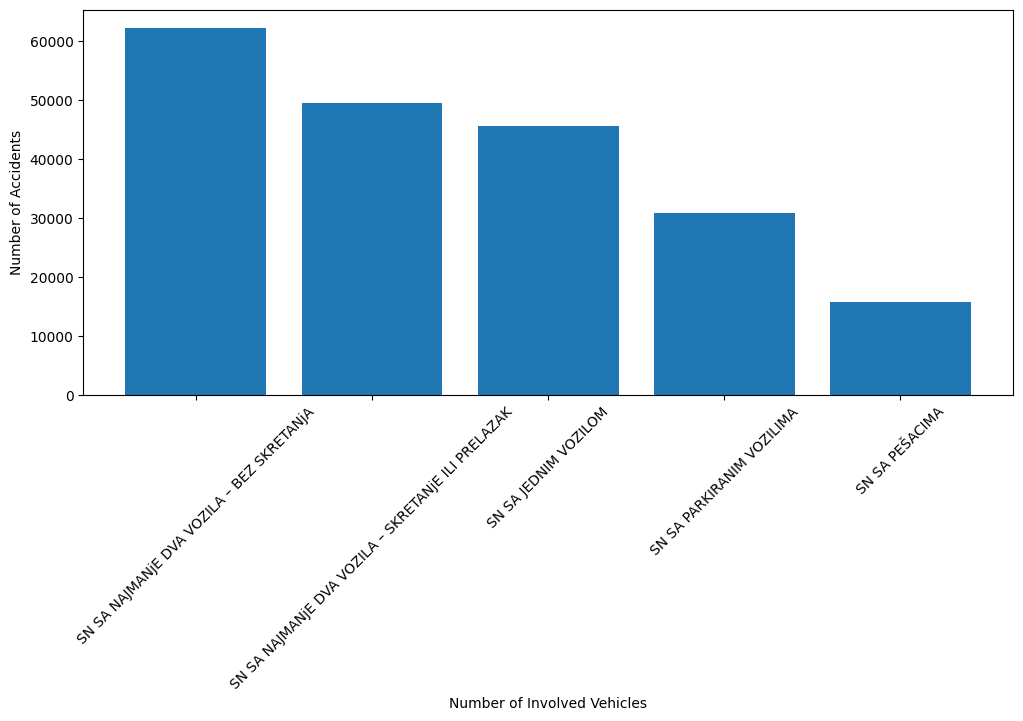

In [37]:
plt.figure(figsize=(12,5))
plt.bar(sorted_by_involved_vehicles_num.index, sorted_by_involved_vehicles_num.values)
plt.xlabel("Number of Involved Vehicles")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

##### **Feature:** `Date and Time`

In [45]:
data['date_time'] = pd.to_datetime(data['date_time'])

data['year'] = data['date_time'].dt.year
data['month'] = data['date_time'].dt.month
data['day_of_week'] = data['date_time'].dt.day_of_week
data['hour'] = data['date_time'].dt.hour

data.drop(columns=["date_time"], inplace=True)

In [46]:
data.head()

,accident_id,department,municipality,longitude,latitude,accident_type,involved_vehicles_num,description,year,month,day_of_week,hour
0,1278576,BEOGRAD,BARAJEVO,20.301589,44.568563,Sa mat.stetom,SN SA JEDNIM VOZILOM,Nezgoda sa jednim vozilom – silazak sa kolovoz...,2020,1,1,10
1,1278948,BEOGRAD,BARAJEVO,20.413280,44.579780,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,2020,1,3,12
2,1278074,BEOGRAD,BARAJEVO,20.312560,44.575470,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću istim putem ...,2020,1,4,10
3,1278582,BEOGRAD,BARAJEVO,20.412190,44.637770,Sa mat.stetom,SN SA NAJMANjE DVA VOZILA – SKRETANjE ILI PREL...,Najmanje dva vozila koja se kreću različitim p...,2020,1,4,15
4,1278638,BEOGRAD,BARAJEVO,20.381686,44.633030,Sa povredjenim,SN SA NAJMANjE DVA VOZILA – BEZ SKRETANjA,Najmanje dva vozila koja se kreću u istom smer...,2020,1,3,16


In [ ]:
sorted_by_year = data.groupby('year').size().sort_values(ascending=False)
sorted_by_year

year
2021    34528
2022    33182
2025    33173
2023    32741
2024    32127
2020    30686
2026     7528
dtype: int64

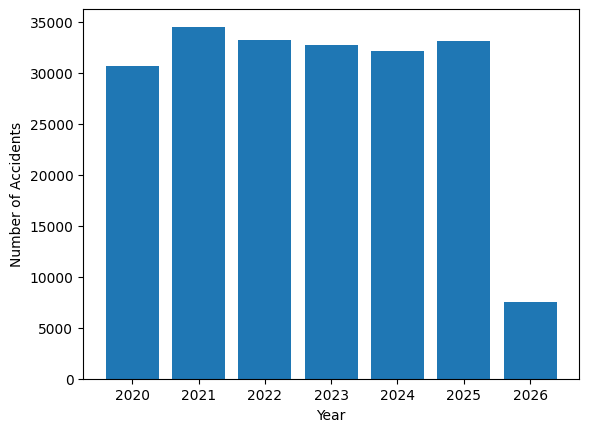

In [60]:
plt.figure()
plt.bar(sorted_by_year.index, sorted_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

In [61]:
sorted_by_month = data.groupby('month').size().sort_values(ascending=False)
sorted_by_month

month
10    18533
12    17834
1     17589
3     17550
9     17525
7     17325
6     17071
8     16914
11    16672
5     16306
2     15949
4     14697
dtype: int64

In [67]:
months = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "July",
    8: "Aug",
    9: "Sept",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

month_labels = [months[m] for m in months]

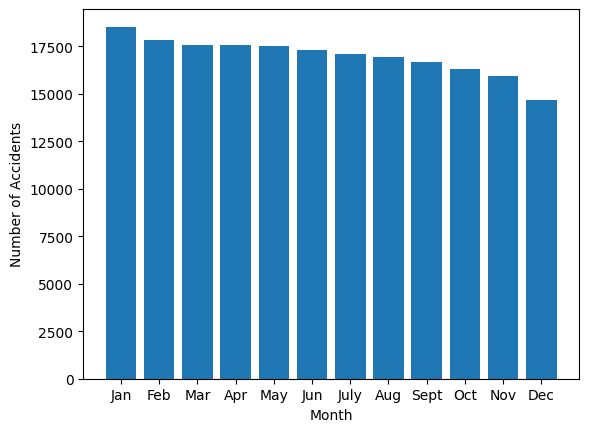

In [68]:
plt.figure()
plt.bar(month_labels, sorted_by_month.values)
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

In [74]:
sorted_by_day = data.groupby('day_of_week').size().sort_values(ascending=False)
sorted_by_day

day_of_week
4    32456
0    30308
3    29660
5    29144
2    29038
1    28585
6    24774
dtype: int64

In [75]:
days = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

day_labels = [days[d] for d in days]

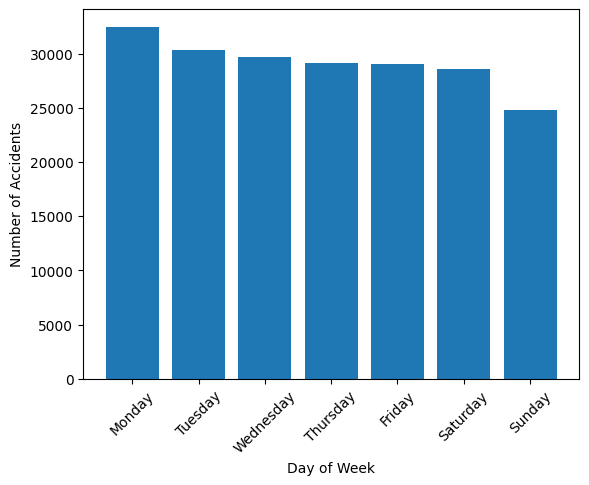

In [77]:
plt.figure()
plt.bar(day_labels, sorted_by_day)
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

In [79]:
sorted_by_hour = data.groupby('hour').size().sort_values(ascending=False)
sorted_by_hour

hour
13    13784
14    13745
15    13667
16    13581
17    13069
12    12628
18    12158
11    11712
19    10752
10    10530
20     9489
9      9045
8      8379
21     8169
7      7735
22     7191
23     5231
6      5074
0      4356
1      3654
2      2932
5      2558
3      2464
4      2062
dtype: int64

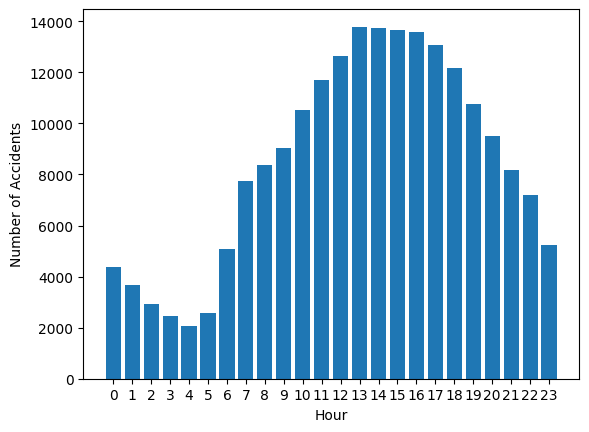

In [80]:
plt.figure()
plt.bar(sorted_by_hour.index, sorted_by_hour.values)
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.show()

### **Multivariate Analysis**

The goal is to check relationships between features trying to find correlation and show them.

### **Conclusions and preparation for ML/modeling**

**Conclusion:**